In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import numpy as np
from triqs.operators import Operator, n
from triqs.gf import MeshImFreq, MeshImTime, Gf, make_gf_from_fourier, iOmega_n, inverse, Fourier
from triqs.plot.mpl_interface import oplot, oploti, oplotr, plt

# One-boson retarded interaction

To showcase the ability to treat retarded interactions in **TRIQS/ctseg**, we consider the minimal discrete model with one fermion (0) coupled to a fermionic bath state (1) as well as a boson

$$
H = \epsilon_0 c^\dagger_0 c_0 + \epsilon_1 c^\dagger_1 c_1 
+ V (c^\dagger_1 c_0 + c^\dagger_0 c_1)
+ g (b + b^\dagger)c^\dagger_0 c_0
+ \omega_0 b^\dagger b
\, .
$$

Integrating out the bath fermion and the boson gives the single fermion action 
$$
\mathcal{S} = 
\int_0^\beta d\tau H_{0}(\tau) 
+ 
\iint_0^\beta d\tau d\tau' c_0^\dagger(\tau) \Delta(\tau - \tau') c_0(\tau)
+
\iint_0^\beta d\tau d\tau' n_0^\dagger(\tau) \mathcal{U}(\tau - \tau') n_0(\tau)
$$
with $H_{0} = \epsilon_0 c^\dagger_0 c_0$, retarded hybridization 
$\Delta(i\nu_n) = \frac{V^2}{i\nu_n - \epsilon_1}$,
and retarded interaction  $\mathcal{U}(i\omega_n) = - 2 g^2 \frac{\omega_0}{\omega_0^2 - (i\omega_n)^2} \,.$

The fermionic Green's function $G_0(\tau) = - \langle \mathcal{T} c_0(\tau) c_0\rangle$ of the action $\mathcal{S}$ can be computed numerically exactly using **TRIQS/ctseg**, and (since the number of states is finite) also using exact diagonalization of $H$. 

## Simulating the retarded action $\mathcal{S}$

To compute the fermionic Green's function $G_0(\tau)$ with **TRIQS/ctseg** we

**1.** set up the system parameters, $\epsilon_0$, $\epsilon_1$, $V$, $g$, and $\omega_0$,

In [2]:
eps0, eps1, V, g, omega0 = -0.1, +0.1, 0.25, 1., 1.
mu = -g**2 / omega0 # For half-filling at eps0 = 0

<p></p>

**2.** construct a solver instance,

In [3]:
from triqs_ctseg import Solver

S = Solver(beta=10., n_tau_bosonic=101,
           gf_struct = [["0", 1], ["1", 1]]); # CTSEG requires two flavours or more, adding one inactive fermion

Starting run with 1 MPI rank(s) at : 2026-02-09 14:42:18.133995


<p></p>

**3.** set the hybridization function $\Delta(i\nu_n) = \frac{V^2}{i\nu_n - \epsilon_1}$,

In [4]:
Delta_iw = make_gf_from_fourier(S.Delta_tau['0'])
Delta_iw << V**2 * inverse(iOmega_n - eps1)
S.Delta_tau['0'] << Fourier(Delta_iw);

<p></p>

**4.** set the retarded interaction $\mathcal{U}(i\omega_n) = - 2g^2 \frac{\omega_0}{ \omega_0^2 - (i\omega_n)^2}$,

In [5]:
D0_iw = make_gf_from_fourier(S.D0_tau['0','0'])
D0_iw << -2 * g**2 * omega0 * inverse(omega0**2 - iOmega_n*iOmega_n);
S.D0_tau["0", "0"] << Fourier(D0_iw);

<p></p>

**5.** and finally, run the solver while passing the Hamiltonian $H_{0} = (\epsilon_0 - \mu) c^\dagger_0 c_0$.

In [6]:
S.solve(h_loc0=(eps0 - mu) * n("0", 0), h_int=Operator(), # No static interaction
        measure_nn_tau=True, length_cycle=16, n_warmup_cycles=int(1e6), n_cycles=int(1e7))


╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┌─┐┌─┐┌─┐
 ║ ╠╦╝║║═╬╗╚═╗  │   │ └─┐├┤ │ ┬
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ └─┘└─┘└─┘


Block: 0    Index: 0    Color: 0
Block: 1    Index: 0    Color: 1

 Interaction matrix: U = 
[[0,0]
 [0,0]] 

Orbital energies: mu - eps = [-0.9,-0] 


 Renormalized interaction matrix: U = 
[[0,0]
 [0,0]] 

Renormalized orbital energies: mu - eps = [0.100822,0] 

Dynamical interactions = true, Jperp interactions = false 


Warming up ...
14:42:18   4% ETA 00:00:01 cycle 47724 of 1000000
14:42:20 100% ETA 00:00:00 cycle 999999 of 1000000



Accumulating ...
14:42:20   0% ETA 00:00:22 cycle 44920 of 10000000
14:42:22   9% ETA 00:00:20 cycle 944507 of 10000000
14:42:24  20% ETA 00:00:17 cycle 2086415 of 10000000
14:42:27  35% ETA 00:00:14 cycle 3503677 of 10000000
14:42:31  52% ETA 00:00:10 cycle 5276400 of 10000000
14:42:36  74% ETA 00:00:05 cycle 7486987 of 10000000
14:42:42 100% ETA 00:00:00 cycle 9999999 of 10000000


[Rank 0] Collect results: Waiting for all mpi-threads to finish accum

## Reference solution from exact diagonalization (using **pyED**)

To get the exact solution we setup the full Hamiltonian $H$ with two fermions and one boson, diagonalize $H$, and compute the single particle Green's function $G_0(\tau)$.

In [7]:
from pyed.SparseExactDiagonalization import SparseExactDiagonalization
from pyed.SparseMatrixFockStates import SparseMatrixFermiBoseCreationOperators

def get_ed_ref(eps0, eps1, V, g, omega0, mesh_tau, Nb_max=10):

    ops = SparseMatrixFermiBoseCreationOperators(Nf=2, Nb=1, Nb_max=Nb_max)
    
    c0, c1, b = ops.c_dag[0].getH(), ops.c_dag[1].getH(), ops.b_dag[0].getH()
    n0, n1, nb = c0.getH() * c0, c1.getH() * c1, b.getH() * b

    H = eps0 * n0 + eps1 * n1  + V*(c1.getH() * c0 + c0.getH() * c1) + g*(b + b.getH())*n0 + omega0 * nb

    ed = SparseExactDiagonalization(H, mesh_tau.beta)

    tau = np.array([float(t) for t in mesh_tau])
    g_tau = Gf(mesh=mesh_tau, target_shape=[1, 1])
    g_tau.data[:, 0, 0] = ed.get_tau_greens_function_component(tau, c0, c0.getH())

    chi_tau = Gf(mesh=mesh_tau, target_shape=[1, 1])
    chi_tau.data[:, 0, 0] = -ed.get_tau_greens_function_component(tau, n0, n0)
    
    return g_tau, chi_tau

<p></p>

## Single particle Green's function

Comparing the single particle Green's function computed with **TRIQS/ctseg** and **pyED** we find excellent agreement.

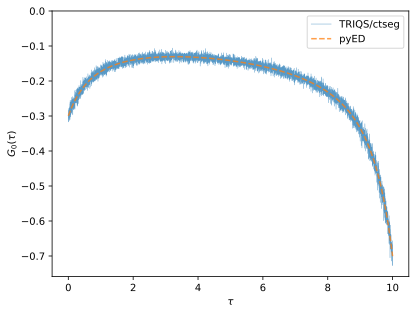

In [8]:
g_tau_ed, chi_tau_ed = get_ed_ref(eps0 - mu, eps1, V, g, omega0, S.Delta_tau.mesh)

oplotr(S.results.G_tau["0"], lw=0.5, alpha=0.75, label=f'TRIQS/ctseg')
oplotr(g_tau_ed, '--',  alpha=0.75, label=f'pyED')
plt.xlabel(r'$\tau$'); plt.ylabel(r'$G_0(\tau)$'); plt.ylim(top=0);

## Dynamic density correlation

Also the density correlation function $\chi(\tau) = \langle \mathcal{T} n_0(\tau) n_0 \rangle$ matches the reference solution from exact diagonalization.

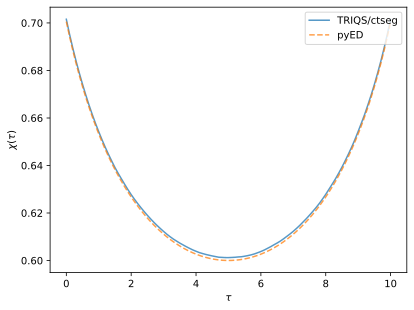

In [9]:
oplotr(S.results.nn_tau['0', '0'], alpha=0.75, label='TRIQS/ctseg')
oplotr(chi_tau_ed, '--', alpha=0.75, label='pyED')
plt.xlabel(r'$\tau$'); plt.ylabel(r'$\chi(\tau)$');